## Les modules

In [2]:
%load_ext autoreload
%autoreload 1
import nbimporter
import time
from tqdm import tqdm
import numpy as np
from sklearn.datasets import make_blobs,make_circles
from sklearn.metrics import accuracy_score
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
#from mpl_toolkits.mplot3d import Axes3D
import tensorflow_datasets as tfds
import matplotlib as mpl

from IPython.display import HTML
from IPython.display import clear_output
from IPython.display import clear_output, display
import os


## Mise à jours

In [428]:
import sys
import importlib
module_nom= ['AtadiaSah','exemple_fonction_indicatrice','Dataset','sah']
for i in module_nom:
    if i in sys.modules:
        del sys.modules[i]
import AtadiaSah as As
importlib.reload(As)
import exemple_fonction_indicatrice as FI
importlib.reload(FI)
import Dataset
importlib.reload(Dataset)
import sah
importlib.reload(sah)

<module 'sah' from 'sah.ipynb'>

## Données (T,V) du virus et normalistion: 

In [429]:
def donne_exerce(m,pas):
    
    T=np.array([1+i*pas for i in range(m)])
    V=np.array([2*T[i]-1+np.random.normal(0,5) for i in range(0,m)])
    T=As.normalisation('min_max',T)
    V=As.normalisation('min_max',V)
    
    def f(a,b,T,V):
        s=[(V[i]-a*T[i]-b)**2 for i in range(m)]
        return np.sum(s)/m
        
    return T,V,f
X,y_x,f=donne_exerce(50,1)
X_test,y_test,f2=donne_exerce(2500,0.2)
X=X.reshape(X.shape[0],1).T
y_x=y_x.reshape(y_x.shape[0],1).T
X_test=X_test.reshape(X_test.shape[0],1).T
y_test=y_test.reshape(y_test.shape[0],1).T
X_test,y_test='non','non'

In [430]:
modele=sah.RN()

c1=As.coucheDense(As.fonction_activation('Leaky_relu',0.1),1,5)
c2=As.coucheDense(As.fonction_activation('Leaky_relu'),1,5)
c3=As.coucheDense(As.fonction_activation('id'),1,1)

modele.add_couche(As.réseau(c1,c2,c3))
modele.add_loss('MSE')
modele.add_regularisation('elasticnet',0,0)
modele.add_optimiseur('DGC','PD_exp',0.001,0,10)                                     #'DGC','PD_exp',0.01,32#SGD
modele.add_score('coefR2')           #Accuracy_score_multiclasse


In [431]:
paramètres,cout1,cout2,score1,score2,temps_ecouler=modele.fil(modele,2000,1,X,y_x,X_test,y_test)

L'architecture du réseau:[1, 5, 5, 1]


Apprentissage:loss_trainset:0.001915572,score_trainset:0.976: 100%|███████████████████████████| 2001/2001 [00:24<00:00, 81.42it/s]

le socre du modèle est de :0.98


In [432]:
#modele.continue_fil(modele,100,1)


In [433]:
#modele.continue_fil_condition(modele,2,2000,0,1)

In [434]:
#modele.graphe2D_approximation(modele,donnée=X,X_fiture='non',y_fiture='non',precision='2D',taille_frontière=1)

In [435]:
mpl.rcParams['animation.embed_limit'] =20000  

In [436]:
nom='résultat_regression25'
X_fiture,y_fiture='non','non'
X_train1=X
a0=('regression','non')
a=(X_train1,X_fiture)
taille_donnée=X
taille=('non','non')
ani,figure=modele.evo(modele,a0,a,taille,1e-3,100) 
figure.savefig(f'C:/Users/GEMSI\Desktop/Mes images ANN mémoire/{nom}.png')

 95%|██████████████████████████████████████████████████████████████████████████████    | 20/21 [00:43<00:01,  1.80s/it]

In [437]:
HTML(ani.to_jshtml())

In [438]:
ani.save(f'C:/Users/GEMSI/Desktop/Mes animation mémoire M2/animation{nom}.mp4', writer='ffmpeg', fps=60)

 99%|███████████████████████████████████████████████████████████████████████████████▏| 100/101 [10:25<00:06,  6.26s/it]


## Solution exacte

In [439]:
a1=np.cov(X,y_x)[0,1]/np.var(X)
b1=np.mean(y_x)-np.mean(X)*a1
droite=lambda t : a1*t+b1

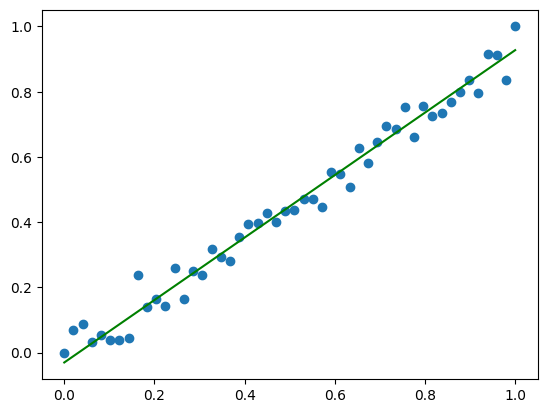

In [440]:
t=np.linspace(0,1,100)
plt.plot(t,droite(t),'green',label='régression_exact')
plt.scatter(X,y_x)
